In [2]:
import pandas as pd 
import joblib
import numpy as np
import sklearn.metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.covariance import EllipticEnvelope
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.svm import SVC, OneClassSVM
from sklearn.manifold import TSNE


## Original Dataset

In [2]:
train_original = pd.read_csv('./DS/train_fold_3.csv')
test_original = pd.read_csv('./DS/test_fold_3.csv')

X_train_original = train_original.drop(['Label'], axis=1)
y_train_original = train_original['Label']
X_test_original = test_original.drop(['Label'], axis=1)
y_test_original = test_original['Label']
label_encoder = LabelEncoder()

y_test_original = label_encoder.fit_transform(y_test_original).astype(np.float32)
y_test_original = pd.Series(y_test_original)
y_train_original = label_encoder.fit_transform(y_train_original).astype(np.float32)
y_train_original = pd.Series(y_train_original)

rf_params = {
    "n_estimators": 900,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}

rf = RandomForestClassifier(**rf_params)
rf.fit(X_train_original, y_train_original)
rf_prediction = rf.predict(X_test_original)

rf_acc = sklearn.metrics.accuracy_score(y_test_original, rf_prediction)
rf_precision = sklearn.metrics.precision_score(y_test_original, rf_prediction, average='macro')
rf_f1 = sklearn.metrics.f1_score(y_test_original, rf_prediction, average='macro')
rf_recall = sklearn.metrics.recall_score(y_test_original, rf_prediction, average='macro')
rf_cm = sklearn.metrics.confusion_matrix(y_test_original, rf_prediction)
rf_probs = rf.predict_proba(X_test_original)
rf_auc = sklearn.metrics.roc_auc_score(y_test_original, rf_probs, average='macro', multi_class='ovr')
print("RandomForest Accuracy:", rf_acc)
print("RandomForest Precision:", rf_precision)
print("RandomForest F1:", rf_f1)
print("RandomForest Recall:", rf_recall)
print("RandomForest ROC AUC:", rf_auc)
print("RandomForest CM:\n", rf_cm)

RandomForest Accuracy: 0.8486193293885601
RandomForest Precision: 0.845781929932378
RandomForest F1: 0.8430652198935542
RandomForest Recall: 0.8486193293885602
RandomForest ROC AUC: 0.9878438016239564
RandomForest CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   0 169   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   1 168   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  36   0   1   0   1  72  33  10  15   0]
 [  0   0   0   0   0   0   0  42 127   0   0   0]
 [  0   0  12   0   0   0   0   5   0 107  45   0]
 [  0   0   0   0   0   0   0   1   0 104  64   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]


# CovaS Framework

## 1. Performance Evaluation

### Autogluon

In [ ]:
X_train_autogluon = X_train_original
X_train_autogluon['label'] = y_train_original
X_test_autogluon = X_test_original
X_test_autogluon['label'] = y_test_original

save_path = 'ag_models' 
predictor = TabularPredictor(path=save_path, label="label").fit(X_train_autogluon, num_gpus=1, verbosity=2)

In [ ]:
preds = predictor.predict(X_test_original)
performance = predictor.evaluate_predictions(y_true=y_test_original, y_pred = preds, auxiliary_metrics=True)

ldb = predictor.leaderboard(X_test_autogluon)
print(ldb) 
print(performance)

### LSTM

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score


train = pd.read_csv('./DS/train_fold_3.csv')
test = pd.read_csv('./DS/test_fold_3.csv')

In [ ]:
class TabularLSTMDataset(Dataset):
    def __init__(self, data, target_col):
        # Separate features and target
        self.X = data.drop(columns=[target_col]).values
        self.y = data[target_col].values
        
        # Scale features
        self.scaler = StandardScaler()
        self.X = self.scaler.fit_transform(self.X)
        
        # Convert to tensors
        self.X = torch.FloatTensor(self.X)
        self.y = torch.FloatTensor(self.y).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMTabularModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1, dropout=0.3):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_size)
        )
    
    def forward(self, x):
        # Ensure input is 3D for LSTM
        if x.dim() == 2:
            x = x.unsqueeze(1)
        
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        return self.fc(out)

def train_lstm_model(train, test, target_col, task_type='multiclass', epochs=100, learning_rate=0.001):
    # Prepare datasets
    train_dataset = TabularLSTMDataset(train, target_col)
    test_dataset = TabularLSTMDataset(test, target_col)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Model initialization with dynamic input size
    input_size = train_dataset.X.shape[1]
    
    # Determine output size based on task type
    if task_type == 'regression':
        output_size = 1
    else:
        output_size = len(np.unique(train[target_col]))
    
    model = LSTMTabularModel(input_size=input_size, output_size=output_size)
    
    # Loss function based on task type
    if task_type == 'regression':
        criterion = nn.MSELoss()
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.squeeze().long() if task_type != 'regression' else batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Calculate training accuracy for classification
            if task_type != 'regression':
                _, predicted = torch.max(outputs.data, 1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y.squeeze().long()).sum().item()
        
        train_accuracy = (train_correct / train_total) * 100 if task_type != 'regression' else None
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, '
              f'Training Accuracy: {train_accuracy:.2f}%' if train_accuracy is not None else f'Loss: {total_loss/len(train_loader):.4f}')
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_preds = []
        for batch_x, _ in test_loader:
            batch_pred = model(batch_x)
            test_preds.append(batch_pred)
        
        test_preds = torch.cat(test_preds).numpy()
    
    # Compute metrics
    if task_type == 'regression':
        true_labels = test[target_col].values if target_col in test.columns else None
        metrics = {
            'MSE': mean_squared_error(true_labels, test_preds) if true_labels is not None else None,
            'MAE': mean_absolute_error(true_labels, test_preds) if true_labels is not None else None,
            'R2': r2_score(true_labels, test_preds) if true_labels is not None else None
        }
    else:
        le = LabelEncoder()
        true_labels = le.fit_transform(test[target_col]) if target_col in test.columns else None
        
        # Convert predictions to class labels
        pred_labels = np.argmax(test_preds, axis=1)
        
        metrics = {
            'Accuracy': accuracy_score(true_labels, pred_labels) if true_labels is not None else None,
            'F1 Score': f1_score(true_labels, pred_labels, average='weighted') if true_labels is not None else None
        }
    
    # Create a copy of test to avoid modification
    test_with_preds = test.copy()
    test_with_preds['Predictions'] = pred_labels if task_type != 'regression' else test_preds
    
    return model, test_with_preds, metrics


def main():
    target_column = 'Label'
    task_type = 'multiclass'  # or 'binary' or 'regression'
    
    model, test_with_predictions, eval_metrics = train_lstm_model(
        train, test, target_column, task_type=task_type
    )
    
    # Print evaluation metrics
    print("Evaluation Metrics:")
    for metric, value in eval_metrics.items():
        print(f"{metric}: {value}")
    
    # Save predictions
    test_with_predictions.to_csv('./DL-model-preds/lstm_predictions.csv', index=False)

if __name__ == '__main__':
    main()

### DNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score

class TabularDataset(Dataset):
    def __init__(self, data, target_col):
        # Separate features and target
        self.X = data.drop(columns=[target_col]).values
        self.y = data[target_col].values
        
        # Scale features
        self.scaler = StandardScaler()
        self.X = self.scaler.fit_transform(self.X)
        
        # Convert to tensors
        self.X = torch.FloatTensor(self.X)
        self.y = torch.FloatTensor(self.y).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class DeepNeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_layers=[128, 64, 32], output_size=1, dropout=0.3):
        super().__init__()
        
        layers = []
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_layers:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size
        
        # Output layer
        layers.append(nn.Linear(prev_size, output_size))
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)


def train_dnn_model(train, test, target_col, task_type='multiclass', epochs=100, learning_rate=0.001):
    # Prepare datasets
    train_dataset = TabularDataset(train, target_col)
    test_dataset = TabularDataset(test, target_col)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # Model initialization with dynamic input size
    input_size = train_dataset.X.shape[1]
    
    # Determine output size based on task type
    if task_type == 'regression':
        output_size = 1
    else:
        output_size = len(np.unique(train[target_col]))
    
    model = DeepNeuralNetwork(input_size=input_size, output_size=output_size)
    
    # Loss function based on task type
    if task_type == 'regression':
        criterion = nn.MSELoss()
    else:
        criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y.squeeze().long() if task_type != 'regression' else batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Calculate training accuracy for classification
            if task_type != 'regression':
                _, predicted = torch.max(outputs.data, 1)
                train_total += batch_y.size(0)
                train_correct += (predicted == batch_y.squeeze().long()).sum().item()
        
        train_accuracy = (train_correct / train_total) * 100 if task_type != 'regression' else None
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}, '
              f'Training Accuracy: {train_accuracy:.2f}%' if train_accuracy is not None else f'Loss: {total_loss/len(train_loader):.4f}')
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_preds = []
        for batch_x, _ in test_loader:
            batch_pred = model(batch_x)
            test_preds.append(batch_pred)
        
        test_preds = torch.cat(test_preds).numpy()
    
    # Compute metrics
    if task_type == 'regression':
        true_labels = test[target_col].values if target_col in test.columns else None
        metrics = {
            'MSE': mean_squared_error(true_labels, test_preds) if true_labels is not None else None,
            'MAE': mean_absolute_error(true_labels, test_preds) if true_labels is not None else None,
            'R2': r2_score(true_labels, test_preds) if true_labels is not None else None
        }
    else:
        le = LabelEncoder()
        true_labels = le.fit_transform(test[target_col]) if target_col in test.columns else None
        
        # Convert predictions to class labels
        pred_labels = np.argmax(test_preds, axis=1)
        
        metrics = {
            'Accuracy': accuracy_score(true_labels, pred_labels) if true_labels is not None else None,
            'F1 Score': f1_score(true_labels, pred_labels, average='weighted') if true_labels is not None else None
        }
    
    # Create a copy of test to avoid modification
    test_with_preds = test.copy()
    test_with_preds['Predictions'] = pred_labels if task_type != 'regression' else test_preds
    
    return model, test_with_preds, metrics

def main():
    target_column = 'Label'
    task_type = 'multiclass'  # or 'binary' or 'regression'
    
    model, test_with_predictions, eval_metrics = train_dnn_model(
        train, test, target_column, task_type=task_type
    )
    
    # Print evaluation metrics
    print("Evaluation Metrics:")
    for metric, value in eval_metrics.items():
        print(f"{metric}: {value}")
    
    # Save predictions
    # test_with_predictions.to_csv('./DL-model-preds/dnn_predictions.csv', index=False)

if __name__ == '__main__':
    main()

## 2. Histogram Overlap Computations

In [12]:
train = pd.read_csv('./DS/train_fold_3.csv')
test  = pd.read_csv('./DS/test_fold_3.csv')

X_train = train.drop(columns=['Label'])
X_test  = test.drop(columns=['Label'])

def histogram_overlap(a: pd.Series, b: pd.Series, bins=100, robust=False):
    # Lọc NaN/Inf
    a = pd.to_numeric(a, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    b = pd.to_numeric(b, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if len(a) == 0 or len(b) == 0:
        return np.nan

    # Chọn khoảng bin
    if robust:
        amin, amax = np.percentile(a, [1, 99])
        bmin, bmax = np.percentile(b, [1, 99])
        min_val, max_val = min(amin, bmin), max(amax, bmax)
    else:
        min_val, max_val = min(a.min(), b.min()), max(a.max(), b.max())

    # Trường hợp feature gần như hằng số
    if not np.isfinite(min_val) or not np.isfinite(max_val) or max_val == min_val:
        return 1.0

    a_hist, bin_edges = np.histogram(a, bins=bins, range=(min_val, max_val), density=False)
    b_hist, _        = np.histogram(b, bins=bins, range=(min_val, max_val), density=False)

    bin_width = bin_edges[1] - bin_edges[0]
    overlap = np.minimum(a_hist, b_hist).sum()
    return float(overlap)

bins = 100
threshold = 0.70

overlap_scores = {}
for feature in X_train.columns:
    ov = histogram_overlap(X_train[feature], X_test[feature], bins=bins, robust=False)
    overlap_scores[feature] = ov

low_overlap_features  = {k: v for k, v in overlap_scores.items() if np.isfinite(v) and v < threshold}
high_overlap_features = {k: v for k, v in overlap_scores.items() if np.isfinite(v) and v >= threshold}

print(f"Total features with overlap < {threshold*100:.0f}%: {len(low_overlap_features)}")
print(f"Total features with overlap ≥ {threshold*100:.0f}%: {len(high_overlap_features)}")

print("\nFeatures with overlap < 70%:")
for feature, overlap in sorted(low_overlap_features.items(), key=lambda x: x[1]):
    print(f"{feature}: {overlap:.3f}")

# Vẽ minh họa feature có overlap thấp nhất
if low_overlap_features:
    least_overlap_feature = min(low_overlap_features, key=low_overlap_features.get)
    a = X_train[least_overlap_feature].dropna().values
    b = X_test[least_overlap_feature].dropna().values
    min_val = min(a.min(), b.min())
    max_val = max(a.max(), b.max())

    plt.figure()
    plt.hist(a, bins=bins, range=(min_val, max_val), density=True, alpha=0.5, label='Train')
    plt.hist(b, bins=bins, range=(min_val, max_val), density=True, alpha=0.5, label='Test')
    plt.legend(loc='upper right')
    plt.xlabel(least_overlap_feature)
    plt.ylabel('Density')
    plt.title(f'Histogram Overlap (≈{low_overlap_features[least_overlap_feature]:.3f}) - {least_overlap_feature}')
    plt.show()

Total features with overlap < 70%: 0
Total features with overlap ≥ 70%: 111

Features with overlap < 70%:


In [8]:
low_overlap_feature_names

[]

In [9]:
autogluon_useless_features = ['flow packet APDU length min', 'flow total IEC104_I_Message_SeqIOA packets', 'fw total IEC104_I_Message_SeqIOA packets', 'bw total IEC104_I_Message_SeqIOA packets', 'fw URG flag amount', 'bw URG flag amount', 'flow SYN flag count', 'flow RST flag count', 'flow URG flag count', 'flow CWE flag count', 'flow ECE flag count', 'cot=2', 'cot=4', 'cot=5', 'cot=8', 'cot=9', 'cot=11', 'cot=12', 'cot=13', 'type_id_system_information_in_monitor_direction', 'type_id_parameter_in_control_direction', 'type_id_file_transfer', 'fw PSH flag amount', 'bw PSH flag amount', 'flow PSH flag count', 'flow ACK flag count']

combined_list = list(set(autogluon_useless_features + low_overlap_feature_names))

len(combined_list)

26

### Save DS after removing useless and overlap features

In [12]:
train_modified = train.drop(columns=autogluon_useless_features, errors='ignore')
test_modified = test.drop(columns=autogluon_useless_features, errors='ignore')

train_modified.to_csv('./DS/train_remove_26_features.csv', index=False)
test_modified.to_csv('./DS/test_remove_26_features.csv', index=False)

print("Modified datasets saved successfully.")

Modified datasets saved successfully.


## 3. Kolomogorov Smirnov Test

In [5]:
train = pd.read_csv('./DS/train_remove_26_features.csv')
test = pd.read_csv('./DS/test_remove_26_features.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train).astype(np.float32)
y_test = label_encoder.transform(y_test).astype(np.float32)
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

ks_results = {}
for feature in X_train.columns:
    statistic, p_value = ks_2samp(X_train[feature], X_test[feature])
    ks_results[feature] = (statistic, p_value)

# Filter features based on p-value < 0.05
significant_features = {k: v for k, v in ks_results.items() if v[1] < 0.05}

# Print the number of significant features
print(f"Total features with p-value < 0.05: {len(significant_features)}")

print("\nSignificant features (p-value < 0.05):")
for feature, (statistic, p_value) in significant_features.items():
    print(f"{feature}: KS Statistic = {statistic:.5f}, p-value = {p_value:.5f}")

critical_value = 1.36 * np.sqrt((len(X_train) + len(X_test)) / (len(X_train) * len(X_test)))
high_ks_features = {k: v for k, v in ks_results.items() if v[0] > critical_value}

print(f"Total features with KS Statistic > Critical value ({critical_value:.5f}): {len(high_ks_features)}")

print("\nFeatures with KS Statistic > Critical value:")
for feature, (statistic, p_value) in high_ks_features.items():
    print(f"{feature}: KS Statistic = {statistic:.5f}, p-value = {p_value:.5f}")

Total features with p-value < 0.05: 5

Significant features (p-value < 0.05):
flow idle time mean: KS Statistic = 0.03755, p-value = 0.03479
flow active time min: KS Statistic = 0.04550, p-value = 0.00526
flow IAT min: KS Statistic = 0.10987, p-value = 0.00000
fw IAT min: KS Statistic = 0.03716, p-value = 0.03784
bw IAT min: KS Statistic = 0.10632, p-value = 0.00000
Total features with KS Statistic > Critical value (0.03602): 5

Features with KS Statistic > Critical value:
flow idle time mean: KS Statistic = 0.03755, p-value = 0.03479
flow active time min: KS Statistic = 0.04550, p-value = 0.00526
flow IAT min: KS Statistic = 0.10987, p-value = 0.00000
fw IAT min: KS Statistic = 0.03716, p-value = 0.03784
bw IAT min: KS Statistic = 0.10632, p-value = 0.00000


In [8]:
KS_features = [feature for feature, (statistic, p_value) in ks_results.items()
                 if p_value < 0.05 or statistic > critical_value]

## 4. Discriminative Distance

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

# Load data
train = pd.read_csv('./DS/train_remove_26_features.csv')
test = pd.read_csv('./DS/test_remove_26_features.csv')

# Prepare features and labels
X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

# Encode labels
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train).astype(np.float32)
y_test = label_encoder.transform(y_test).astype(np.float32)
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)

# Combine train and test data for discriminative distance analysis
X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = pd.concat([pd.Series(1, index=X_train.index), pd.Series(0, index=X_test.index)], axis=0)

# --- Random Forest Classifier ---
print("\n--- Random Forest ---")
rf_params = {
    "n_estimators": 500,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 42,
    "bootstrap": True,
    "criterion": "entropy"
}

rf_classifier = RandomForestClassifier(**rf_params)
cv_scores_rf = cross_val_score(rf_classifier, X_combined, y_combined, cv=10, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores (RF): {cv_scores_rf}")
print(f"Mean Cross-Validation Accuracy (RF): {np.mean(cv_scores_rf) * 100:.2f}%")

# --- XGBoost Classifier ---
print("\n--- XGBoost ---")
xgb_classifier = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
cv_scores_xgb = cross_val_score(xgb_classifier, X_combined, y_combined, cv=10, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores (XGBoost): {cv_scores_xgb}")
print(f"Mean Cross-Validation Accuracy (XGBoost): {np.mean(cv_scores_xgb) * 100:.2f}%")

# --- Extra Trees Classifier ---
print("\n--- Extra Trees ---")
et_params = {
    "n_estimators": 500,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 42,
    "bootstrap": True,
    "criterion": "entropy"
}

et_classifier = ExtraTreesClassifier(**et_params)
cv_scores_et = cross_val_score(et_classifier, X_combined, y_combined, cv=10, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores (Extra Trees): {cv_scores_et}")
print(f"Mean Cross-Validation Accuracy (Extra Trees): {np.mean(cv_scores_et) * 100:.2f}%")


--- Random Forest ---
Cross-Validation Accuracy Scores (RF): [0.68081991 0.62371889 0.66617862 0.62811127 0.60175695 0.70717423
 0.71303075 0.72474378 0.69061584 0.69941349]
Mean Cross-Validation Accuracy (RF): 67.36%

--- XGBoost ---
Cross-Validation Accuracy Scores (XGBoost): [0.68228404 0.62079063 0.66178624 0.66617862 0.64714495 0.6954612
 0.68667643 0.73792094 0.69354839 0.43548387]
Mean Cross-Validation Accuracy (XGBoost): 65.27%

--- Extra Trees ---
Cross-Validation Accuracy Scores (Extra Trees): [0.6749634  0.6398243  0.65885798 0.62371889 0.59150805 0.69692533
 0.70278184 0.71010249 0.67741935 0.70674487]
Mean Cross-Validation Accuracy (Extra Trees): 66.83%


## 5. 2D Visualiazation

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6828 samples in 0.002s...
[t-SNE] Computed neighbors for 6828 samples in 1.378s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6828
[t-SNE] Computed conditional probabilities for sample 2000 / 6828
[t-SNE] Computed conditional probabilities for sample 3000 / 6828
[t-SNE] Computed conditional probabilities for sample 4000 / 6828
[t-SNE] Computed conditional probabilities for sample 5000 / 6828
[t-SNE] Computed conditional probabilities for sample 6000 / 6828
[t-SNE] Computed conditional probabilities for sample 6828 / 6828
[t-SNE] Mean sigma: 0.024024
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.067162
[t-SNE] KL divergence after 1000 iterations: 0.355831


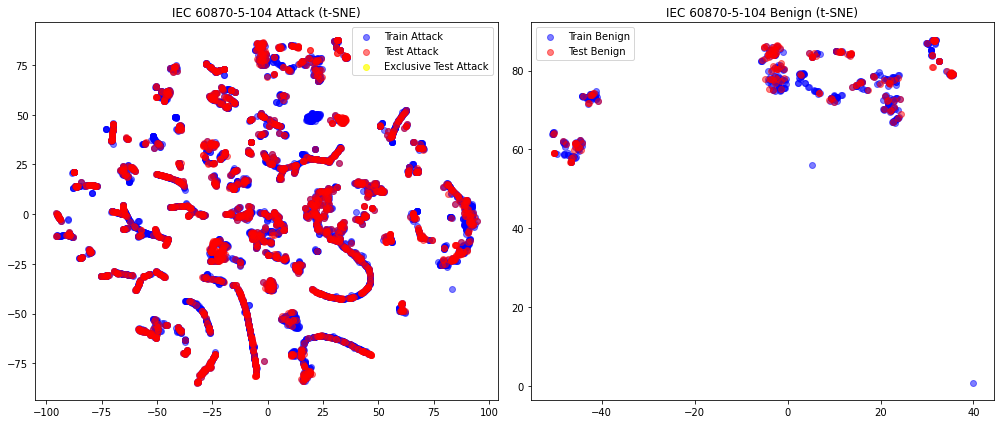

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ====== load ======
train = pd.read_csv('./DS/train_remove_26_features.csv')
test  = pd.read_csv('./DS/test_remove_26_features.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test  = test.drop(['Label'], axis=1)
y_test  = test['Label']

# ====== encode labels ======
label_encoder = LabelEncoder()
y_train = pd.Series(label_encoder.fit_transform(y_train).astype(np.float32))
y_test  = pd.Series(label_encoder.transform(y_test).astype(np.float32))

# ====== combine ======
X_combined = pd.concat([X_train, X_test], axis=0, ignore_index=True)

# ====== QUAN TRỌNG: ép về numeric float ======
# 1) Lấy đúng các cột numeric (nếu có cột text)
num_cols = X_combined.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) < X_combined.shape[1]:
    print(f"[WARN] Loại bỏ {X_combined.shape[1]-len(num_cols)} cột không phải số:", 
          list(set(X_combined.columns) - set(num_cols)))
X_combined = X_combined[num_cols]

# 2) Ép numeric phòng trường hợp cột numeric bị lẫn string
X_combined = X_combined.apply(pd.to_numeric, errors='coerce')

# 3) Xử lý giá trị bất thường
X_combined = X_combined.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# 4) Chuẩn hóa (tốt cho khoảng cách trong t-SNE)
scaler = StandardScaler(with_mean=True, with_std=True)
X_combined_scaled = scaler.fit_transform(X_combined).astype(np.float64)  # đảm bảo float

# ====== (tuỳ chọn) PCA tiền xử lý để tăng tốc TSNE ======
USE_PCA_PRE = True
PCA_PRE_NC  = min(50, X_combined_scaled.shape[1]) if X_combined_scaled.shape[1] > 2 else X_combined_scaled.shape[1]
if USE_PCA_PRE and PCA_PRE_NC > 0:
    pca_pre = PCA(n_components=PCA_PRE_NC, random_state=42)
    X_for_tsne = pca_pre.fit_transform(X_combined_scaled)
else:
    X_for_tsne = X_combined_scaled

# ====== t-SNE ======
# Lưu ý: perplexity < (n_samples - 1)
perplexity = 30 if X_for_tsne.shape[0] > 50 else max(5, min(10, X_for_tsne.shape[0]-1))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,       # dùng số để tương thích các bản sklearn cũ
    n_iter=1000,
    init='pca',
    random_state=42,
    metric='euclidean',
    verbose=1
)
X_tsne = tsne.fit_transform(X_for_tsne)  # ==> giờ là float, không còn '<U32'

# ====== split lại ======
n_tr = len(X_train)
X_tsne_train = X_tsne[:n_tr]
X_tsne_test  = X_tsne[n_tr:]

# ====== mask như cũ ======
train_labels = set(y_train.unique())
test_labels  = set(y_test.unique())
exclusive_test_attacks = test_labels - train_labels

train_attack          = (y_train.isin(train_labels - exclusive_test_attacks))
test_attack           = (y_test.isin(train_labels - exclusive_test_attacks))
exclusive_test_attack = (y_test.isin(exclusive_test_attacks))

train_benign = (y_train == 0)
test_benign  = (y_test == 0)

# ====== plot ======
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_tsne_train[train_attack, 0], X_tsne_train[train_attack, 1],
            c='blue', alpha=0.5, label='Train Attack')
plt.scatter(X_tsne_test[test_attack, 0], X_tsne_test[test_attack, 1],
            c='red', alpha=0.5, label='Test Attack')
plt.scatter(X_tsne_test[exclusive_test_attack, 0], X_tsne_test[exclusive_test_attack, 1],
            c='yellow', alpha=0.7, label='Exclusive Test Attack')
plt.title('IEC 60870-5-104 Attack (t-SNE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_tsne_train[train_benign, 0], X_tsne_train[train_benign, 1],
            c='blue', alpha=0.5, label='Train Benign')
plt.scatter(X_tsne_test[test_benign, 0], X_tsne_test[test_benign, 1],
            c='red', alpha=0.5, label='Test Benign')
plt.title('IEC 60870-5-104 Benign (t-SNE)')
plt.legend()

plt.tight_layout()
plt.show()


### LSTM

In [ ]:
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
# Load data
import pandas as pd
train = pd.read_csv('./DS/train_remove_26_features.csv')
test = pd.read_csv('./DS/test_remove_26_features.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

# Encode labels
label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test).astype(np.float32)
y_test = pd.Series(y_test)
y_train = label_encoder.fit_transform(y_train).astype(np.float32)
y_train = pd.Series(y_train)

# Combine train and test data for discriminative distance analysis
X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = pd.concat([pd.Series(1, index=X_train.index), pd.Series(0, index=X_test.index)], axis=0)
# Define Dataset Class
class TabularLSTMDataset(Dataset):
    def __init__(self, X, y):
        self.scaler = StandardScaler()
        self.X = self.scaler.fit_transform(X)
        self.X = torch.FloatTensor(self.X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define LSTM Model
class LSTMTabularModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_size=1, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_size)
        )
    
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        return self.fc(out)

# Perform K-Fold Cross Validation
def train_lstm_kfold(X, y, task_type='multiclass', k=10, epochs=10, learning_rate=0.001):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    acc_scores = []
    f1_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        train_dataset = TabularLSTMDataset(X_train, y_train)
        val_dataset = TabularLSTMDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
        
        input_size = X.shape[1]
        output_size = len(np.unique(y)) if task_type != 'regression' else 1
        model = LSTMTabularModel(input_size=input_size, output_size=output_size)
        
        criterion = nn.CrossEntropyLoss() if task_type != 'regression' else nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        for epoch in range(epochs):
            model.train()
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_x)
                # loss = criterion(outputs, batch_y.squeeze().long() if task_type != 'regression' else batch_y)
                loss = criterion(outputs, batch_y.view(-1).long() if task_type != 'regression' else batch_y)
                loss.backward()
                optimizer.step()
        
        # Evaluate model
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_pred = model(batch_x)
                pred_labels = torch.argmax(batch_pred, axis=1) if task_type != 'regression' else batch_pred.squeeze()
                all_preds.extend(pred_labels.numpy())
                all_labels.extend(batch_y.numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        acc_scores.append(acc)
        f1_scores.append(f1)
    
    print(f"Mean Accuracy (LSTM): {np.mean(acc_scores) * 100:.2f}%")
    print(f"Mean F1 Score (LSTM): {np.mean(f1_scores) * 100:.2f}%")
    return np.mean(acc_scores), np.mean(f1_scores)

# Run the LSTM model with KFold
mean_acc, mean_f1 = train_lstm_kfold(X_combined.values, y_combined.values, task_type='multiclass')


### DNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Load data
train = pd.read_csv('./DS/train_remove_26_features.csv')
test = pd.read_csv('./DS/test_remove_26_features.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

# Encode labels
label_encoder = LabelEncoder()
y_test = label_encoder.fit_transform(y_test).astype(np.float32)
y_test = pd.Series(y_test)
y_train = label_encoder.fit_transform(y_train).astype(np.float32)
y_train = pd.Series(y_train)

# Combine train and test data
X_combined = pd.concat([X_train, X_test], axis=0)
y_combined = pd.concat([pd.Series(1, index=X_train.index), pd.Series(0, index=X_test.index)], axis=0)

# Define Dataset Class
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.scaler = StandardScaler()
        self.X = self.scaler.fit_transform(X)
        self.X = torch.FloatTensor(self.X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define DNN Model
class DNNModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=1, dropout=0.3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.fc(x)

# Perform K-Fold Cross Validation
def train_dnn_kfold(X, y, task_type='multiclass', k=10, epochs=10, learning_rate=0.001):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    acc_scores = []
    f1_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        train_dataset = TabularDataset(X_train, y_train)
        val_dataset = TabularDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
        
        input_size = X.shape[1]
        output_size = len(np.unique(y)) if task_type != 'regression' else 1
        model = DNNModel(input_size=input_size, output_size=output_size)
        
        criterion = nn.CrossEntropyLoss() if task_type != 'regression' else nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        for epoch in range(epochs):
            model.train()
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y.view(-1).long() if task_type != 'regression' else batch_y)
                loss.backward()
                optimizer.step()
        
        # Evaluate model
        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_pred = model(batch_x)
                pred_labels = torch.argmax(batch_pred, axis=1) if task_type != 'regression' else batch_pred.squeeze()
                all_preds.extend(pred_labels.numpy())
                all_labels.extend(batch_y.numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='weighted')
        acc_scores.append(acc)
        f1_scores.append(f1)
    
    print(f"Mean Accuracy (DNN): {np.mean(acc_scores) * 100:.2f}%")
    print(f"Mean F1 Score (DNN): {np.mean(f1_scores) * 100:.2f}%")
    return np.mean(acc_scores), np.mean(f1_scores)

# Run the DNN model with KFold
mean_acc, mean_f1 = train_dnn_kfold(X_combined.values, y_combined.values, task_type='multiclass')


## 6. SHAP based Feature Importance

In [7]:
import shap
from sklearn.ensemble import ExtraTreesClassifier

train = pd.read_csv('./DS/train_remove_26_features.csv')
test = pd.read_csv('./DS/test_remove_26_features.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']
X_test = test.drop(['Label'], axis=1)
y_test = test['Label']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train).astype(np.float32)
y_test = label_encoder.transform(y_test).astype(np.float32)
y_train = pd.Series(y_train)
y_test = pd.Series(y_test)
labels = label_encoder.classes_

In [32]:
rf_params = {
    "n_estimators": 90,
    "max_leaf_nodes": 10000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}


print("RandomForestClassifier Starting")
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X=X_train, y=y_train)
rf_preds = rf_model.predict(X_test)
rf_acc = sklearn.metrics.accuracy_score(rf_preds, y_test)
print("RandomForestClassifier Accuracy:", rf_acc)

RandomForestClassifier Starting
RandomForestClassifier Accuracy: 0.8525641025641025


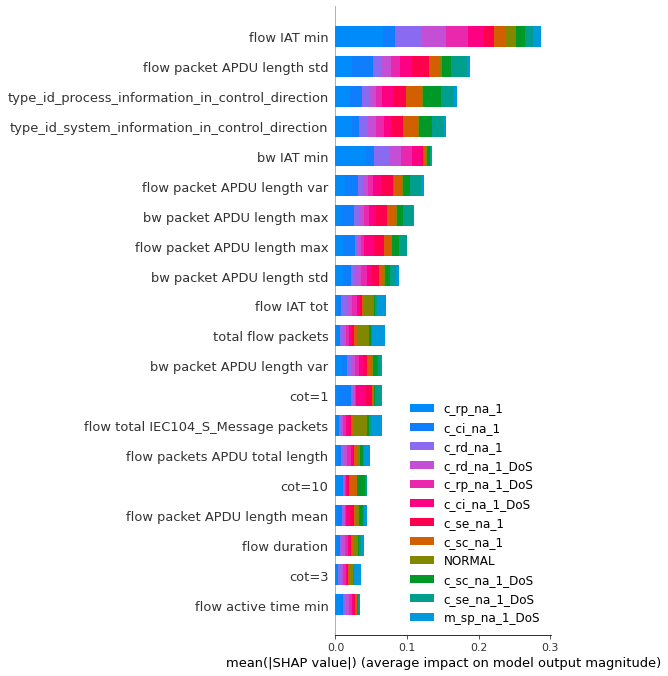

In [21]:
explainer = shap.Explainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=labels, show=False)

In [23]:
mean_abs_shap_values = np.mean(np.abs(shap_values), axis=(0, 1))

feature_ranking = pd.DataFrame({'Feature': X_test.columns, 'Mean Absolute SHAP Value': mean_abs_shap_values})

feature_ranking = feature_ranking.sort_values(by='Mean Absolute SHAP Value', ascending=False)

print(feature_ranking)

                                             Feature  Mean Absolute SHAP Value
13                                      flow IAT min              2.389927e-02
33                       flow packet APDU length std              1.566870e-02
83  type_id_process_information_in_control_direction              1.413962e-02
84   type_id_system_information_in_control_direction              1.287166e-02
15                                        bw IAT min              1.123417e-02
..                                               ...                       ...
69                                  bw avg bulk rate              1.936441e-05
57                 fw total IEC104_S_Message packets              1.686761e-05
36                         fw packet APDU length min              6.566703e-06
66                                 fw avg bytes/bulk              3.516039e-06
70                               fw avg packets/bulk              3.609685e-07

[85 rows x 2 columns]


## Kiểm tra độ quan trọng của các features có p-value < 0.05

In [26]:
drop_feature_importance = feature_ranking[feature_ranking['Feature'].isin(KS_features)]

print(drop_feature_importance)

                 Feature  Mean Absolute SHAP Value
13          flow IAT min                  0.023899
15            bw IAT min                  0.011234
6   flow active time min                  0.002895
14            fw IAT min                  0.002355
2    flow idle time mean                  0.002083


In [55]:
threshold = 0.0005
selected_features = feature_ranking[feature_ranking['Mean Absolute SHAP Value'] > threshold]['Feature'].tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
print(len(selected_features))

66


In [57]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
print(len(selected_features))

rf_params = {
    "n_estimators": 200,
    "max_leaf_nodes": 15000,
    "n_jobs": -1,
    "random_state": 0,
    "bootstrap": True,
    "criterion": "entropy"
}


print("RandomForestClassifier Starting")
rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X=X_train_selected, y=y_train)
rf_preds = rf_model.predict(X_test_selected)
rf_acc = sklearn.metrics.accuracy_score(y_test, rf_preds)
print("RandomForestClassifier Accuracy:", rf_acc)

66
RandomForestClassifier Starting
RandomForestClassifier Accuracy: 0.854043392504931


### Save DS

In [58]:
new_train = X_train_selected.copy()
new_train['Label'] = y_train
new_test = X_test_selected.copy()
new_test['Label'] = y_test

new_train.to_csv(f'./DS/train_shap_{len(selected_features)}.csv',index=False)
new_test.to_csv(f'./DS/test_shap_{len(selected_features)}.csv',index=False)